# Variational AutoEncoders

[Pablo Carballeira] (http://dymas.ii.uam.es/webvpu/gti/user/186/), Escuela Politecnica Superior, Universidad Autónoma de Madrid.

Parts of this code have been adapted from the work of Justin Johnson (https://web.eecs.umich.edu/~justincj/), Electrical Engineering and Computer Science (EECS), University of Michigan.

You can find documentation about working in Colab here (https://colab.research.google.com/notebooks/intro.ipynb)


## Instructions

Anywhere you see a **???** in the code below, fill in in with the correct code.


# Variational Autoencoder

**Discriminative models** take an input and are trained to produce a labeled output. In this notebook, we will expand our repetoire, and build **generative models** using neural networks. Specifically, we will learn how to build models which generate novel images that resemble a set of training images.

For approaches to generative modeling check out the [deep generative model chapter](http://www.deeplearningbook.org/contents/generative_models.html) of the Deep Learning [book](http://www.deeplearningbook.org). A popular way of training neural networks as generative models is Variational Autoencoders (co-discovered [here](https://arxiv.org/abs/1312.6114) and [here](https://arxiv.org/abs/1401.4082)). Variational autoencoders combine neural networks with variational inference to train deep generative models. These models tend to be far stable and easy to train but currently, although they usually don't produce samples that are as pretty as those produced by GANs.

In this notebook, you will implement a variational autoencoder and a conditional variational autoencoder with slightly different architectures and apply them to the popular MNIST handwritten dataset. An autoencoder seeks to learn a latent representation of the training images by using unlabeled data and learning to reconstruct its inputs. The *variational autoencoder* extends this model by adding a probabilistic spin to the encoder and decoder, allowing us to sample from the learned distribution of the latent space to generate new images at inference time.

## Setup Code
Before getting started, we need to run some boilerplate code to set up the  environment. You'll need to rerun this setup code each time you start the notebook. First, run this cell load the autoreload extension. This allows us to edit .py source files, and re-import them into the notebook for a seamless editing and debugging experience.


In [1]:
import sys
import types
import importlib

# Workaround for Python 3.12
imp = types.ModuleType("imp")
imp.reload = importlib.reload
sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

### Google Colab Setup
Next we need to run a few commands to set up our environment on Google Colab. If you are running this notebook on a local machine you can skip this section.

Run the following cell to mount your Google Drive. Follow the link, sign in to your Google account (the same account you used to store this notebook!) and copy the authorization code into the text box that appears below.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now recall the path in your Google Drive where you uploaded this notebook, fill it in below. If everything is working correctly then running the folowing cell should print the filenames from the assignment:


In [ ]:
import os

# TODO: Fill in the Google Drive path where you uploaded the assignment
# Example: If you create a DL4VSP2 folder and put all the files under P2 folder, then 'DL4ISP/P2'
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'DLVSP/DLVSP2/Lab2'

GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

['a6_helper.py', '__pycache__', 'cvae_hyperparameter_results', 'vae_generation_latent15_hidden128.jpg', 'vae_cond_generation_latent15_hidden128.jpg', '[UAM-DL4VSP2]variational_autoencoders.ipynb']


Once you have successfully mounted your Google Drive and located the path to
this assignment, run the following cell to allow us to import from the `.py` files of this assignment. If it works correctly, it should print the message:

```
Hello from a6_helper.py!
```

In [ ]:
import sys
sys.path.append(GOOGLE_DRIVE_PATH)

import time, os
os.environ["TZ"] = "US/Eastern"
time.tzset()

from a6_helper import hello_helper
hello_helper()

Hello from a6_helper.py!


Load several useful packages that are used in this notebook:

In [ ]:
from a6_helper import rel_error
from a6_helper import reset_seed
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
import torchvision
import torchvision.transforms as T
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as dset

import matplotlib.pyplot as plt
%matplotlib inline


# for plotting
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['font.size'] = 16
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

We will use GPUs to accelerate our computation in this notebook. Run the following to make sure GPUs are enabled:

In [ ]:
if torch.cuda.is_available():
    print('Good to go!')
else:
    print('Please set GPU via Edit -> Notebook Settings.')

Good to go!


## Load MNIST Dataset


VAEs (and GANs as you'll see in the next notebook) are notoriously finicky with hyperparameters, and also require many training epochs. In order to make this assignment approachable, we will be working on the MNIST dataset, which has 60,000 training and 10,000 test images. Each picture contains a centered image of white digit on black background (0 through 9). This was one of the first datasets used to train convolutional neural networks and it is fairly easy -- a standard CNN model can easily exceed 99% accuracy.

To simplify our code here, we will use the PyTorch MNIST wrapper, which downloads and loads the MNIST dataset. See the [documentation](https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py) for more information about the interface. The default parameters will take 5,000 of the training examples and place them into a validation dataset. The data will be saved into a folder called `MNIST_data`.

In [ ]:
batch_size = 128

mnist_train = dset.MNIST('./MNIST_data', train=True, download=True,
                           transform=T.ToTensor())
loader_train = DataLoader(mnist_train, batch_size=batch_size,
                          shuffle=True, drop_last=True, num_workers=2)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.76MB/s]


## Visualize dataset

It is always a good idea to look at examples from the dataset before working with it. Let's visualize the digits in the MNIST dataset. We have defined the function `show_images` in `a6_helper.py` that we call to visualize the images.


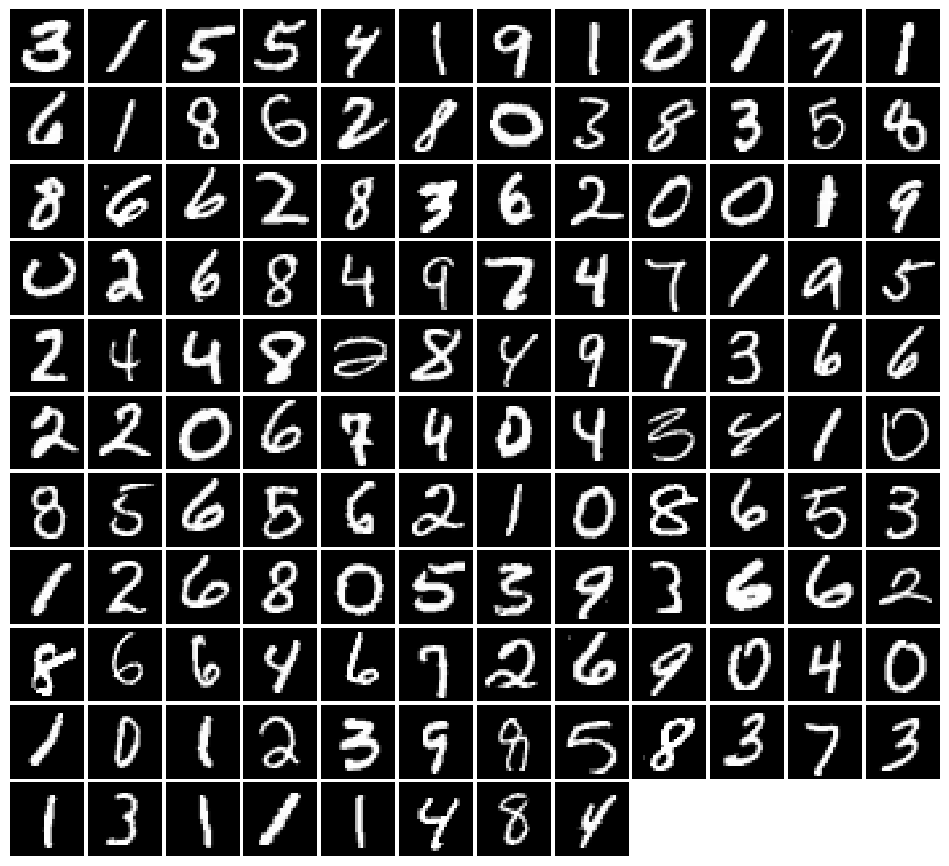

In [ ]:
from a6_helper import show_images

imgs = next(iter(loader_train))[0].view(batch_size, 784)
show_images(imgs)

# Reparametrization trick

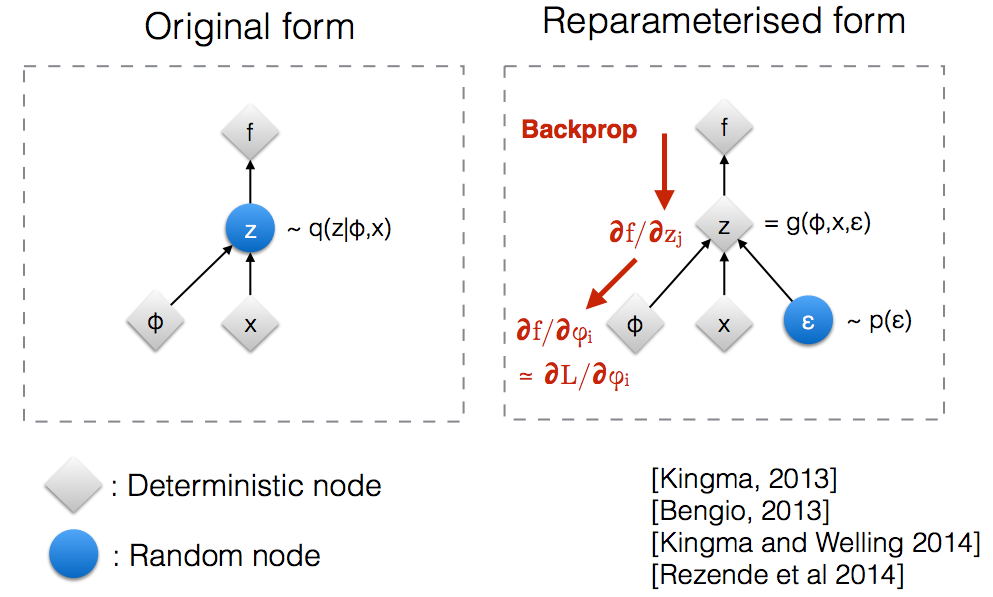

Here we implement a reparametrization trick that we will apply to sample over $z$ during the forward pass, given the $\mu$ and $\sigma^2$ estimated by the encoder. The trivial way to do this is simply generate a normal distribution centered at the estimated $\mu$ and having a std corresponding to the estimated $\sigma^2$. However, we would have to backpropogate through this random sampling that is not differentiable.

Instead, we can sample initial random data $\epsilon$ from a fixed distrubtion, and compute $z$ as a function of ($\epsilon$, $\sigma^2$, $\mu$). Specifically:

$z = \mu + \sigma\epsilon$

We can easily find the partial derivatives w.r.t $\mu$ and $\sigma^2$ and backpropagate through $z$. If $\epsilon = \mathcal{N} (0,1)$, then it's easy to verify that the result of our forward pass calculation will be a distribution centered at $\mu$ with variance $\sigma^2$.

Implement `reparametrization` and verify your mean and std error are at or less than `1e-4`.

In [ ]:
def reparametrize(mu, logvar):
    """
    Differentiably sample random Gaussian data with specified mean and variance
    using the reparameterization trick.

    Inputs:
    - mu: Tensor of shape (N, Z) giving means
    - logvar: Tensor of shape (N, Z) giving log-variances

    Returns:
    - z: Estimated latent vectors
    """

    ###############################################################################
    # TODO: Reparametrize by initializing epsilon as a normal distribution and      #
    # scaling by posterior mu and sigma to estimate z                              #
    ###############################################################################

    std = torch.exp(0.5 * logvar)      # sigma = sqrt(var) = exp(0.5 * logvar)
    eps = torch.randn_like(std)        # epsilon ~ N(0, 1), same shape/device
    z = mu + std * eps                 # z = mu + sigma * epsilon

    ###############################################################################
    #                              END OF YOUR CODE                               #
    ###############################################################################
    return z

In [ ]:
reset_seed(0)

latent_size = 15
size = (1, latent_size)
mu = torch.zeros(size)
logvar = torch.ones(size)

z = reparametrize(mu, logvar)

expected_mean = torch.FloatTensor([-0.4363])
expected_std = torch.FloatTensor([1.6860])
z_mean = torch.mean(z, dim=-1)
z_std = torch.std(z, dim=-1)
assert z.size() == size

print('Mean Error', rel_error(z_mean, expected_mean))
print('Std Error', rel_error(z_std, expected_std))

Mean Error 5.639056398351415e-05
Std Error 7.1412955526273885e-06


# Fully Connected VAE

Our first VAE implementation will consist solely of fully connected layers. We'll take the `1 x 28 x 28` shape of our input and flatten the features to create an input dimension size of 784. In this section you'll define the Encoder and Decoder models in the VAE class, implement a reparametrization trick, forward pass, and loss function to train your first VAE.

## FC-VAE Encoder

Now lets start building our fully-connected VAE network. We'll start with the encoder, which will take our images as input (after flattening C,H,W to D shape) and pass them through three Linear+ReLU layers. We'll use this hidden dimension representation to predict both the posterior mu and posterior log-variance using two separate linear layers (both shape (N,Z)).

Note that we are calling this the 'logvar' layer because we'll use the log-variance (instead of variance or standard deviation) to stabilize training. This will specifically matter more when you compute reparametrization and the loss function later.

*Define an `encoder`, `hidden_dim` (H), `mu_layer`, and `logvar_layer` in the initialization of the VAE class. Use nn.Sequential to define the encoder, and separate Linear layers for the mu and logvar layers. In all of these layers, H will be a hidden dimension you set and will be the same across all encoder and decoder layers. Architecture for the encoder is described below:*


 * `Flatten` (Hint: nn.Flatten)
 * Fully connected layer with input size 784 (`input_size`) and output size H
 * `ReLU`
 * Fully connected layer with input_size H and output size H
 * `ReLU`
 * Fully connected layer with input_size H and output size H
 * `ReLU`


## FC-VAE Decoder

We'll now define the decoder, which will take the latent space representation and generate a reconstructed image. The architecture is as follows:

 * Fully connected layer with input size as the latent size (Z) and output size H
 * `ReLU`
 * Fully connected layer with input_size H and output size H
 * `ReLU`
 * Fully connected layer with input_size H and output size H
 * `ReLU`
 * Fully connected layer with input_size H and output size 784 (`input_size`)
 * `Sigmoid`
 * `Unflatten` (nn.Unflatten)

*Define a `decoder` in the initialization of the VAE class. Like the encoding step, use `nn.Sequential`*  



## FC-VAE Forward

Complete the VAE class by writing the forward pass. The forward pass should pass the input image through the encoder to calculate the estimation of mu and logvar, reparametrize to estimate the latent space z, and finally pass z into the decoder to generate an image.



In [ ]:
class VAE(nn.Module):
    def __init__(self, input_size, latent_size=15, hidden_dim=128):
        super(VAE, self).__init__()

        self.input_size = input_size      # H*W, for MNIST = 784
        self.latent_size = latent_size    # Z
        self.hidden_dim = hidden_dim      # H_dim

        ###########################################################################
        # Encoder
        ###########################################################################

        self.encoder = nn.Sequential(
            nn.Flatten(),                              # (N, 1, 28, 28) -> (N, 784)
            nn.Linear(input_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mu_layer = nn.Linear(hidden_dim, latent_size)
        self.logvar_layer = nn.Linear(hidden_dim, latent_size)

        ###########################################################################
        # Decoder
        ###########################################################################

        self.decoder = nn.Sequential(
            nn.Linear(latent_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_size),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))               # (N, 784) -> (N, 1, 28, 28)
        )

    def forward(self, x):
        """
        Performs forward pass through FC-VAE model.
        """

        ###########################################################################
        # Forward pass
        ###########################################################################

        hidden = self.encoder(x)

        mu = self.mu_layer(hidden)
        logvar = self.logvar_layer(hidden)

        z = reparametrize(mu, logvar)

        x_hat = self.decoder(z)

        ###########################################################################
        #                                      END OF YOUR CODE                   #
        ###########################################################################

        return x_hat, mu, logvar

## Loss Function

Before we're able to train our final model, we'll need to define our loss function. As seen below, the loss function for VAEs contains two terms: A reconstruction loss term (left) and KL divergence term (right).

$-E_{Z~q_{\phi}(z|x)}[log p_{\theta}(x|z)] + D_{KL}(q_{\phi}(z|x), p(z)))$

Note that this is the negative of the variational lowerbound shown in lecture--this ensures that when we are minimizing this loss term, we're maximizing the variational lowerbound. The reconstruction loss term can be computed by simply using the binary cross entropy loss between the original input pixels and the output pixels of our decoder (Hint: `nn.functional.binary_cross_entropy`). The KL divergence term works to force the latent space distribution to be close to the prior distribution (we're using a standard normal gaussian as our prior).

Here is the unvectorized form of the KL divergence term .
Suppose that $q_\phi(z|x)$ is a $Z$-dimensional diagonal Gaussian with mean $\mu_{z|x}$ of shape $(Z,)$ and standard deviation $\sigma_{z|x}$ of shape $(Z,)$, and that $p(z)$ is a $Z$-dimensional Gaussian with zero mean and unit variance. Then we can write the KL divergence term as:

$D_{KL}(q_{\phi}(z|x), p(z))) = -\frac{1}{2} \sum_{j=1}^{J} (1 + log(\sigma_{z|x}^2)_{j} - (\mu_{z|x})^2_{j} - (\sigma_{z|x})^2_{j}$)

where $J$ indicates the number of samples in the minibatch. It's up to you to implement a vectorized version of this loss that operates on minibatches.
You should average the loss across samples in the minibatch.

Implement `loss_function` and verify your implementation below. Your relative error should be less than or equal to `1e-5`



In [ ]:
def loss_function(x_hat, x, mu, logvar):
    """
    Computes the negative variational lower bound loss term of the VAE.

    Inputs:
    - x_hat: Reconstruced input data of shape (N, 1, H, W)
    - x: Input data of shape (N, 1, H, W)
    - mu: Estimated posterior mean of shape (N, Z)
    - logvar: Estimated posterior log-variance of shape (N, Z)

    Returns:
    - loss: Scalar VAE loss
    """

    ###############################################################################
    # Reconstruction loss: binary cross entropy
    # Sum over all pixels, then average over batch.
    ###############################################################################
    N = x.shape[0]

    recon_loss = F.binary_cross_entropy(
        x_hat,
        x,
        reduction='sum'
    ) / N

    ###############################################################################
    # KL divergence loss:
    # -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    # Sum over latent dimensions and batch, then average over batch.
    ###############################################################################
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - torch.exp(logvar)
    ) / N

    loss = recon_loss + kl_loss

    ###############################################################################
    #                            END OF YOUR CODE                                 #
    ###############################################################################
    return loss

In [ ]:
size = (1,15)

image = torch.sigmoid(torch.FloatTensor([[2,5], [6,7]]).unsqueeze(0).unsqueeze(0))
image_hat = torch.sigmoid(torch.FloatTensor([[1,10], [9,3]]).unsqueeze(0).unsqueeze(0))

expected_out = torch.tensor(8.5079)
mu, logvar = torch.ones(size), torch.zeros(size)
out = loss_function(image, image_hat, mu, logvar)
print('Loss error', rel_error(expected_out,out))

Loss error 2.1297676389877955e-06



## Train a model

Now that we have our VAE defined and loss function ready, lets train our model! Our training script is provided  in `a6_helper.py`, and we have pre-defined an Adam optimizer, learning rate, and # of epochs for you to use.

Training for 10 epochs should take ~2 minutes and your loss should be less than 120.

In [ ]:
def one_hot(labels, class_size):
    """
    Create one hot label matrix of size (N, C)

    Inputs:
    - labels: Labels Tensor of shape (N,) representing a ground-truth label
    for each MNIST image
    - class_size: Scalar representing of target classes our dataset
    Outputs:
    - targets: One-hot label matrix of (N, C), where targets[i, j] = 1 when
    the ground truth label for image i is j, and targets[i, :j] &
    targets[i, j + 1:] are equal to 0
    """
    targets = torch.zeros(labels.size(0), class_size)
    for i, label in enumerate(labels):
        targets[i, label] = 1
    return targets

In [ ]:
def train_vae(epoch, model, train_loader, cond=False):
    """
    Train a VAE or CVAE!

    Inputs:
    - epoch: Current epoch number
    - model: VAE model object
    - train_loader: PyTorch Dataloader object that contains our training data
    - cond: Boolean value representing whether we're training a VAE or
      Conditional VAE
    """
    model.train()
    train_loss = 0
    num_classes = 10
    loss = None

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)

        if cond:
            ###############################################################################
            # TODO: obtain the forward pass of the CVAE, combining samples and labels     #
            ###############################################################################

            labels_onehot = one_hot(labels, num_classes).to(device)
            recon_batch, mu, logvar = model(data, labels_onehot)

            ###########################################################################
            #                                      END OF YOUR CODE                   #
            ###########################################################################
        else:
            recon_batch, mu, logvar = model(data)

        optimizer.zero_grad()

        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.data

        optimizer.step()

    print("Train Epoch: {} \tLoss: {:.6f}".format(epoch, loss.data))

In [ ]:
num_epochs = 10
input_size = 28*28

# variable parameters
latent_size = 15
hidden_dim = 128

# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

vae_model = VAE(input_size, latent_size=latent_size, hidden_dim=hidden_dim)
vae_model.to(device)
for epoch in range(0, num_epochs):
    train_vae(epoch, vae_model, loader_train)

Using device: cuda
Train Epoch: 0 	Loss: 184.415863
Train Epoch: 1 	Loss: 155.015182
Train Epoch: 2 	Loss: 138.336868
Train Epoch: 3 	Loss: 134.369980
Train Epoch: 4 	Loss: 129.969437
Train Epoch: 5 	Loss: 122.678093
Train Epoch: 6 	Loss: 124.773125
Train Epoch: 7 	Loss: 126.479675
Train Epoch: 8 	Loss: 117.030029
Train Epoch: 9 	Loss: 117.203789


## Visualize results

After training our VAE network, we're able to take advantage of its power to generate new training examples. This process simply involves the decoder: we intialize some random distribution for our latent spaces z, and generate new examples by passing these latent space into the decoder.

Run the cell below to generate new images! You should be able to visually recognize many of the digits, although some may be a bit blurry or badly formed. Our next model will see improvement in these results.

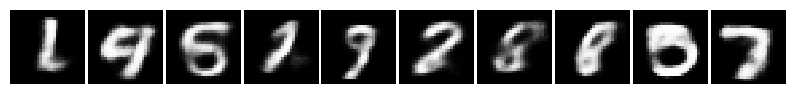

In [ ]:
z = torch.randn(10, latent_size).to(device)

import matplotlib.gridspec as gridspec
vae_model.eval()
samples = vae_model.decoder(z).data.cpu().numpy()

save_file = f'vae_generation_latent{latent_size}_hidden{hidden_dim}.jpg'

fig = plt.figure(figsize=(10, 1))
gspec = gridspec.GridSpec(1, 10)
gspec.update(wspace=0.05, hspace=0.05)
for i, sample in enumerate(samples):
    ax = plt.subplot(gspec[i])
    plt.axis('off')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')
    plt.imshow(sample.reshape(28,28), cmap='Greys_r')
    plt.savefig(os.path.join(GOOGLE_DRIVE_PATH,save_file))

## Latent Space Interpolation

As a final visual test of our trained VAE model, we can perform interpolation in latent space. We generate random latent vectors $z_0$ and $z_1$, and linearly interpolate between them; we run each interpolated vector through the trained generator to produce an image.

Each row of the figure below interpolates between two random vectors. For the most part the model should exhibit smooth transitions along each row, demonstrating that the model has learned something nontrivial about the underlying spatial structure of the digits it is modeling.

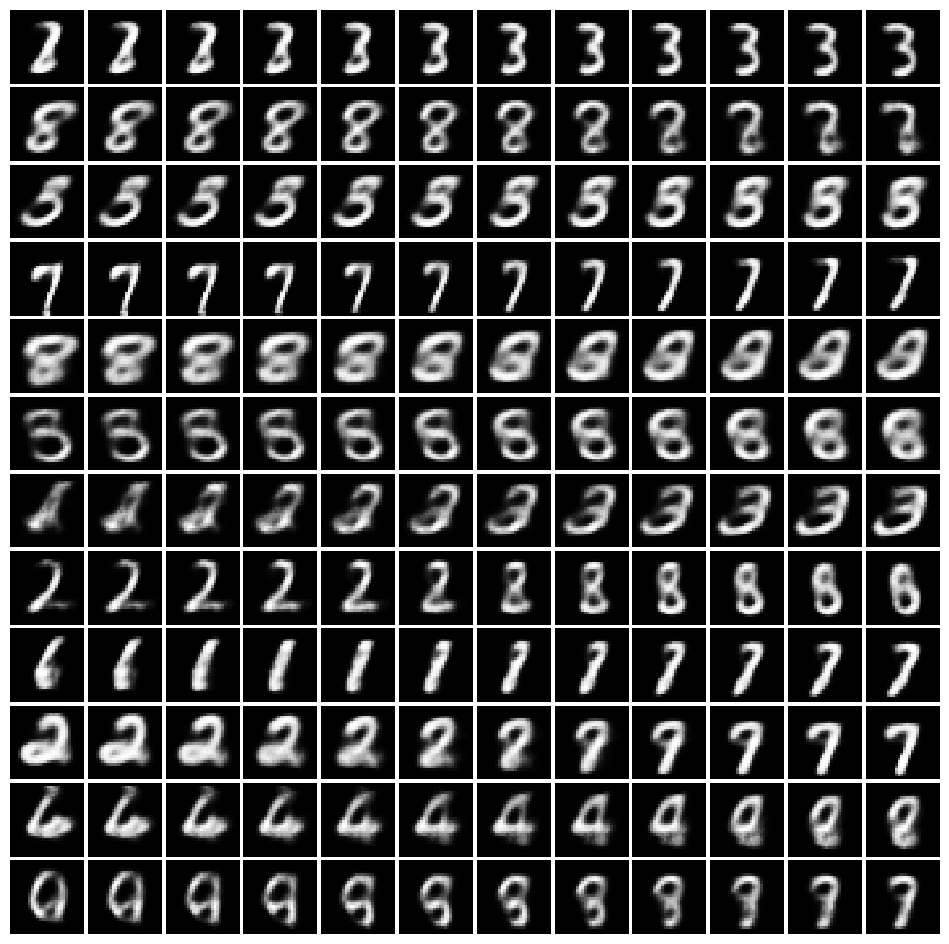

In [ ]:
S = 12 # number of samples
latent_size = 15
z0 = torch.randn(S,latent_size , device=device)
z1 = torch.randn(S, latent_size, device=device)
w = torch.linspace(0, 1, S, device=device).view(S, 1, 1)
z = (w * z0 + (1 - w) * z1).transpose(0, 1).reshape(S * S, latent_size)
x = vae_model.decoder(z)
show_images(x.data.cpu())

# Conditional FC-VAE

The second model you'll develop will be very similar to the FC-VAE, but with a slight conditional twist to it. We'll use what we know about the labels of each MNIST image, and *condition* our latent space and image generation on the specific class. Instead of $q_{\phi} (z|x)$ and $p_{\phi}(x|z)$ we have $q_{\phi} (z|x,c)$  and $p_{\phi}(x|z, c)$

This will allow us to do some powerful conditional generation at inference time. We can specifically choose to generate more 1s, 2s, 9s, etc. instead of simply generating new digits randomly.

## Define Network with class input

Our CVAE architecture will be the same as our FC-VAE architecture, except we'll now add a one-hot label vector to both the x input (in our case, the flattened image dimensions) and the z latent space.

If our one-hot vector is called `c`, then `c[label] = 1` and `c = 0` elsewhere.

For the `CVAE` class use the same FC-VAE architecture implemented in the last network with the following modifications:

1. Modify the first linear layer of your `encoder` to take in not only the flattened input image, but also the one-hot label vector `c`
2. Modify the first layer of your `decoder` to project the latent space + one-hot vector to the `hidden_dim`
3. Lastly, implement the `forward` pass to combine the flattened input image with the one-hot vectors (`torch.cat`) before passing them to the `encoder` and combine the latent space with the one-hot vectors (`torch.cat`) before passing them to the `decoder`

## Train model

Using the same training script, let's now train our CVAE!

Training for 10 epochs should take ~2 minutes and your loss should be less than 120.

In [ ]:
class CVAE(nn.Module):
    def __init__(self, input_size, num_classes=10, latent_size=15, hidden_dim=128):
        super(CVAE, self).__init__()

        self.input_size = input_size        # H*W, for MNIST = 784
        self.latent_size = latent_size      # Z
        self.num_classes = num_classes      # C
        self.hidden_dim = hidden_dim        # H_dim

        ###########################################################################
        # Encoder: input is flattened image + one-hot class vector
        # Shape: (N, input_size + num_classes) -> (N, hidden_dim)
        ###########################################################################

        self.encoder = nn.Sequential(
            nn.Linear(input_size + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mu_layer = nn.Linear(hidden_dim, latent_size)
        self.logvar_layer = nn.Linear(hidden_dim, latent_size)

        ###########################################################################
        # Decoder: input is latent vector + one-hot class vector
        # Shape: (N, latent_size + num_classes) -> (N, 1, 28, 28)
        ###########################################################################

        self.decoder = nn.Sequential(
            nn.Linear(latent_size + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_size),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x, c):
        """
        Performs forward pass through FC-CVAE model.

        Inputs:
        - x: Input data of shape (N, 1, H, W)
        - c: One-hot class vector of shape (N, C)

        Returns:
        - x_hat: Reconstructed input data of shape (N, 1, H, W)
        - mu: Estimated posterior mean of shape (N, Z)
        - logvar: Estimated posterior log-variance of shape (N, Z)
        """

        ###########################################################################
        # (1) Flatten x and concatenate with class vector c
        ###########################################################################

        x_flat = torch.flatten(x, start_dim=1)       # (N, 1, 28, 28) -> (N, 784)
        encoder_input = torch.cat([x_flat, c], dim=1)

        hidden = self.encoder(encoder_input)

        mu = self.mu_layer(hidden)
        logvar = self.logvar_layer(hidden)

        ###########################################################################
        # (2) Reparametrize to sample latent vector z
        ###########################################################################

        z = reparametrize(mu, logvar)

        ###########################################################################
        # (3) Concatenate z with class vector c and decode
        ###########################################################################

        decoder_input = torch.cat([z, c], dim=1)
        x_hat = self.decoder(decoder_input)

        ###########################################################################
        #                                      END OF YOUR CODE                   #
        ###########################################################################

        return x_hat, mu, logvar

Go back to train_vae() and modify it to handle conditional training. Image samples need to be accompanied by one-hot encoded versions of classes

In [ ]:
num_epochs = 10
input_size = 28*28

# variable parameters
latent_size = 15
hidden_dim = 128

cvae = CVAE(input_size, latent_size=latent_size)
cvae.to(device)
for epoch in range(0, num_epochs):
    train_vae(epoch, cvae, loader_train, cond=True)

Train Epoch: 0 	Loss: 156.945831
Train Epoch: 1 	Loss: 137.529724
Train Epoch: 2 	Loss: 127.415390
Train Epoch: 3 	Loss: 132.953857
Train Epoch: 4 	Loss: 122.099861
Train Epoch: 5 	Loss: 122.488739
Train Epoch: 6 	Loss: 118.175125
Train Epoch: 7 	Loss: 116.538544
Train Epoch: 8 	Loss: 116.748932
Train Epoch: 9 	Loss: 118.289497


## Visualize Results

We've trained our CVAE, now let's conditionally generate some new data! This time, we can specify the class we want to generate by adding our one hot matrix of class labels. We use `torch.eye` to create an identity matrix, which effectively gives us one label for each digit. When you run the cell below, you should get one example per digit. Each digit should be reasonably distinguishable (it is ok to run this cell a few times to save your best results).



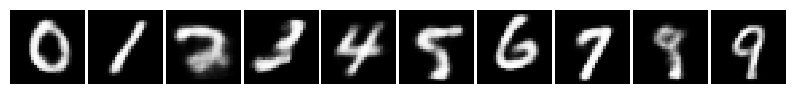

In [ ]:
z = torch.randn(10, latent_size)
c = torch.eye(10, 10) # [one hot labels for 0-9]
import matplotlib.gridspec as gridspec
z = torch.cat((z,c), dim=-1).to(device)
cvae.eval()
samples = cvae.decoder(z).data.cpu().numpy()

save_file = f'vae_cond_generation_latent{latent_size}_hidden{hidden_dim}.jpg'

fig = plt.figure(figsize=(10, 1))
gspec = gridspec.GridSpec(1, 10)
gspec.update(wspace=0.05, hspace=0.05)
for i, sample in enumerate(samples):
    ax = plt.subplot(gspec[i])
    plt.axis('off')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect('equal')
    plt.imshow(sample.reshape(28, 28), cmap='Greys_r')
    plt.savefig(os.path.join(GOOGLE_DRIVE_PATH,save_file))

## Evaluate image synthesis quality and hyperparameter effect

Once you have completed the code for training and running VAE and CVAE, let's evaluate the influence of hyperparameters such as `latent_size` and `hidden_dim` for the CVAE model. Evaluate the effect of those values in the quality of generated samples. Evaluate (independently) different values for those hyperparameters and qualitatively measure the quality.

Include those results in the report and indicate which are the optimal values in a subective basis. Indicate in the analysisi if there are differences in the obtained quality for different classes (different numbers).

Note that in the generation examples included in the notebook, we save the files indicating the value of `latent_size` and `hidden_dim` used for that speecific experiment for your convinience. We encourage you to generate the appropiate code to automatize this process


Training CVAE: latent_size=2, hidden_dim=128
latent_size= 2, hidden_dim=128, epoch= 1/10, mean_loss=193.7094
latent_size= 2, hidden_dim=128, epoch= 2/10, mean_loss=148.4603
latent_size= 2, hidden_dim=128, epoch= 3/10, mean_loss=141.1228
latent_size= 2, hidden_dim=128, epoch= 4/10, mean_loss=138.0110
latent_size= 2, hidden_dim=128, epoch= 5/10, mean_loss=136.2403
latent_size= 2, hidden_dim=128, epoch= 6/10, mean_loss=135.0289
latent_size= 2, hidden_dim=128, epoch= 7/10, mean_loss=134.1095
latent_size= 2, hidden_dim=128, epoch= 8/10, mean_loss=133.3871
latent_size= 2, hidden_dim=128, epoch= 9/10, mean_loss=132.8489
latent_size= 2, hidden_dim=128, epoch=10/10, mean_loss=132.4334


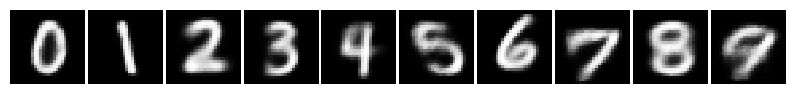


Training CVAE: latent_size=5, hidden_dim=128
latent_size= 5, hidden_dim=128, epoch= 1/10, mean_loss=196.6500
latent_size= 5, hidden_dim=128, epoch= 2/10, mean_loss=151.4225
latent_size= 5, hidden_dim=128, epoch= 3/10, mean_loss=136.1518
latent_size= 5, hidden_dim=128, epoch= 4/10, mean_loss=128.7024
latent_size= 5, hidden_dim=128, epoch= 5/10, mean_loss=125.6719
latent_size= 5, hidden_dim=128, epoch= 6/10, mean_loss=123.8063
latent_size= 5, hidden_dim=128, epoch= 7/10, mean_loss=122.3842
latent_size= 5, hidden_dim=128, epoch= 8/10, mean_loss=121.3282
latent_size= 5, hidden_dim=128, epoch= 9/10, mean_loss=120.5140
latent_size= 5, hidden_dim=128, epoch=10/10, mean_loss=119.6984


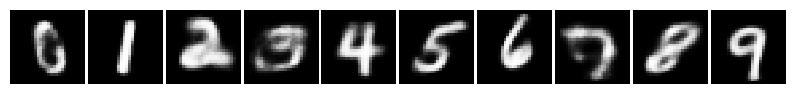


Training CVAE: latent_size=10, hidden_dim=128
latent_size=10, hidden_dim=128, epoch= 1/10, mean_loss=199.8519
latent_size=10, hidden_dim=128, epoch= 2/10, mean_loss=149.7391
latent_size=10, hidden_dim=128, epoch= 3/10, mean_loss=135.0776
latent_size=10, hidden_dim=128, epoch= 4/10, mean_loss=128.3889
latent_size=10, hidden_dim=128, epoch= 5/10, mean_loss=123.6350
latent_size=10, hidden_dim=128, epoch= 6/10, mean_loss=120.0785
latent_size=10, hidden_dim=128, epoch= 7/10, mean_loss=117.7528
latent_size=10, hidden_dim=128, epoch= 8/10, mean_loss=116.0390
latent_size=10, hidden_dim=128, epoch= 9/10, mean_loss=114.6593
latent_size=10, hidden_dim=128, epoch=10/10, mean_loss=113.6057


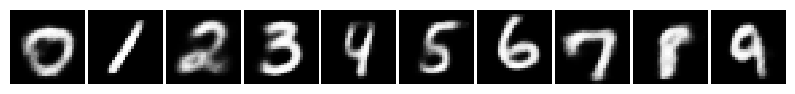


Training CVAE: latent_size=15, hidden_dim=128
latent_size=15, hidden_dim=128, epoch= 1/10, mean_loss=198.9062
latent_size=15, hidden_dim=128, epoch= 2/10, mean_loss=148.0252
latent_size=15, hidden_dim=128, epoch= 3/10, mean_loss=133.1944
latent_size=15, hidden_dim=128, epoch= 4/10, mean_loss=125.4454
latent_size=15, hidden_dim=128, epoch= 5/10, mean_loss=120.9395
latent_size=15, hidden_dim=128, epoch= 6/10, mean_loss=118.1446
latent_size=15, hidden_dim=128, epoch= 7/10, mean_loss=116.3194
latent_size=15, hidden_dim=128, epoch= 8/10, mean_loss=114.9507
latent_size=15, hidden_dim=128, epoch= 9/10, mean_loss=113.8258
latent_size=15, hidden_dim=128, epoch=10/10, mean_loss=112.8215


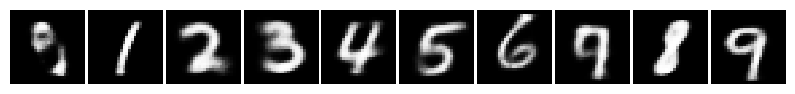


Training CVAE: latent_size=30, hidden_dim=128
latent_size=30, hidden_dim=128, epoch= 1/10, mean_loss=201.3408
latent_size=30, hidden_dim=128, epoch= 2/10, mean_loss=152.6204
latent_size=30, hidden_dim=128, epoch= 3/10, mean_loss=135.1978
latent_size=30, hidden_dim=128, epoch= 4/10, mean_loss=126.3888
latent_size=30, hidden_dim=128, epoch= 5/10, mean_loss=121.9849
latent_size=30, hidden_dim=128, epoch= 6/10, mean_loss=119.2163
latent_size=30, hidden_dim=128, epoch= 7/10, mean_loss=117.1937
latent_size=30, hidden_dim=128, epoch= 8/10, mean_loss=115.6502
latent_size=30, hidden_dim=128, epoch= 9/10, mean_loss=114.5021
latent_size=30, hidden_dim=128, epoch=10/10, mean_loss=113.5801


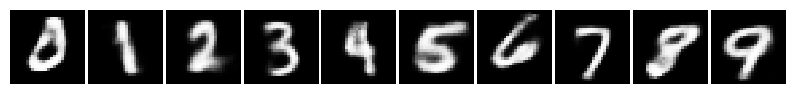


Training CVAE: latent_size=15, hidden_dim=32
latent_size=15, hidden_dim= 32, epoch= 1/10, mean_loss=229.3757
latent_size=15, hidden_dim= 32, epoch= 2/10, mean_loss=184.1195
latent_size=15, hidden_dim= 32, epoch= 3/10, mean_loss=171.2495
latent_size=15, hidden_dim= 32, epoch= 4/10, mean_loss=160.5064
latent_size=15, hidden_dim= 32, epoch= 5/10, mean_loss=151.2370
latent_size=15, hidden_dim= 32, epoch= 6/10, mean_loss=145.6878
latent_size=15, hidden_dim= 32, epoch= 7/10, mean_loss=141.5491
latent_size=15, hidden_dim= 32, epoch= 8/10, mean_loss=138.1905
latent_size=15, hidden_dim= 32, epoch= 9/10, mean_loss=135.6166
latent_size=15, hidden_dim= 32, epoch=10/10, mean_loss=133.9028


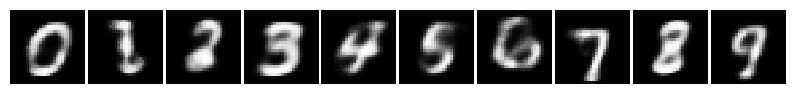


Training CVAE: latent_size=15, hidden_dim=64
latent_size=15, hidden_dim= 64, epoch= 1/10, mean_loss=214.8232
latent_size=15, hidden_dim= 64, epoch= 2/10, mean_loss=167.1806
latent_size=15, hidden_dim= 64, epoch= 3/10, mean_loss=148.5893
latent_size=15, hidden_dim= 64, epoch= 4/10, mean_loss=138.1538
latent_size=15, hidden_dim= 64, epoch= 5/10, mean_loss=133.0504
latent_size=15, hidden_dim= 64, epoch= 6/10, mean_loss=129.8156
latent_size=15, hidden_dim= 64, epoch= 7/10, mean_loss=127.4600
latent_size=15, hidden_dim= 64, epoch= 8/10, mean_loss=125.6230
latent_size=15, hidden_dim= 64, epoch= 9/10, mean_loss=124.1948
latent_size=15, hidden_dim= 64, epoch=10/10, mean_loss=123.1774


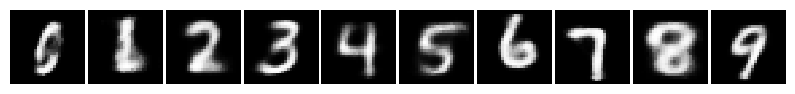


Training CVAE: latent_size=15, hidden_dim=256
latent_size=15, hidden_dim=256, epoch= 1/10, mean_loss=187.3227
latent_size=15, hidden_dim=256, epoch= 2/10, mean_loss=139.9578
latent_size=15, hidden_dim=256, epoch= 3/10, mean_loss=128.1963
latent_size=15, hidden_dim=256, epoch= 4/10, mean_loss=123.9886
latent_size=15, hidden_dim=256, epoch= 5/10, mean_loss=120.0251
latent_size=15, hidden_dim=256, epoch= 6/10, mean_loss=116.8570
latent_size=15, hidden_dim=256, epoch= 7/10, mean_loss=114.9661
latent_size=15, hidden_dim=256, epoch= 8/10, mean_loss=113.5699
latent_size=15, hidden_dim=256, epoch= 9/10, mean_loss=112.4135
latent_size=15, hidden_dim=256, epoch=10/10, mean_loss=111.6204


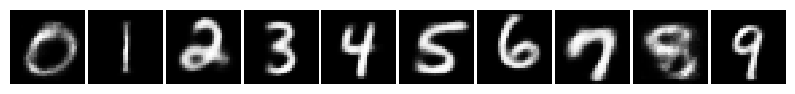


Saved qualitative sweep table to: drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperparameter_results/qualitative_independent_sweeps.csv
latent_size sweep | latent_size=2 | hidden_dim=128


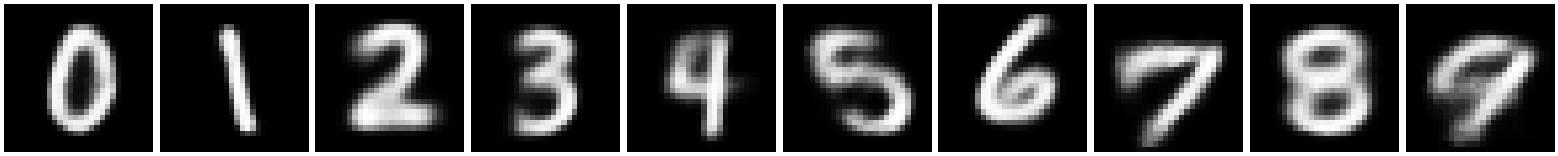

latent_size sweep | latent_size=5 | hidden_dim=128


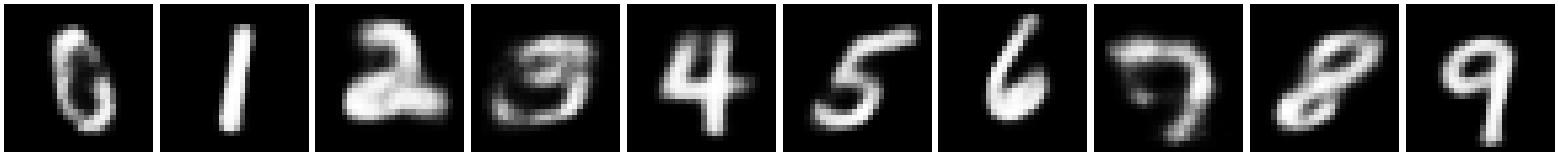

latent_size sweep | latent_size=10 | hidden_dim=128


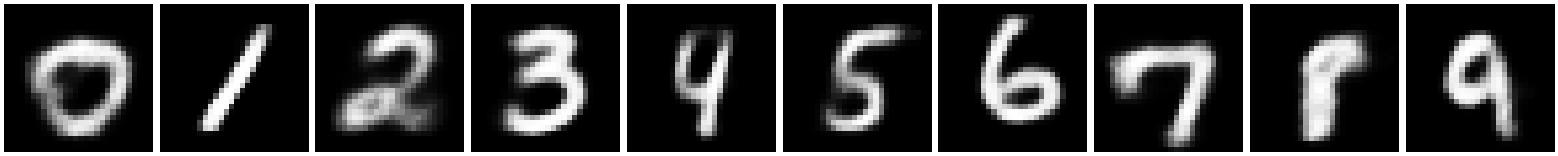

latent_size sweep | latent_size=15 | hidden_dim=128


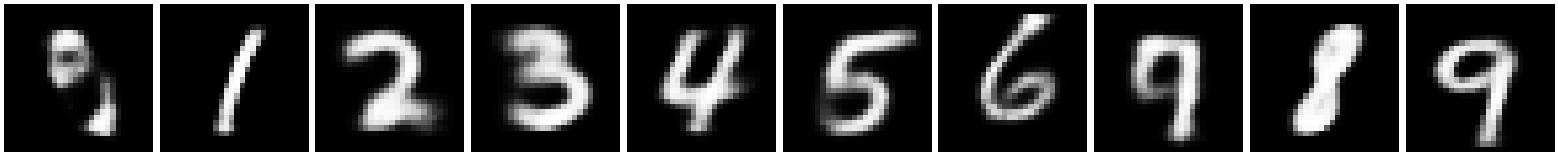

latent_size sweep | latent_size=30 | hidden_dim=128


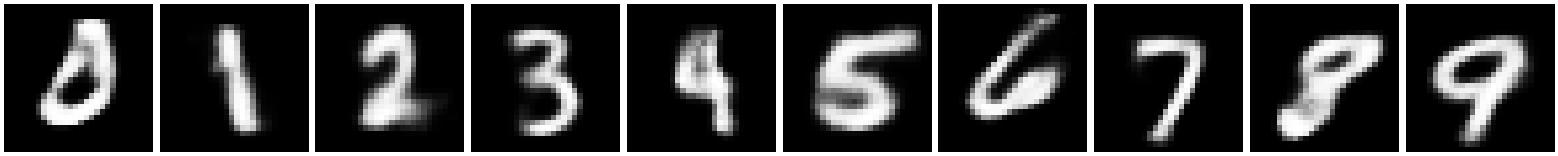

hidden_dim sweep | latent_size=15 | hidden_dim=32


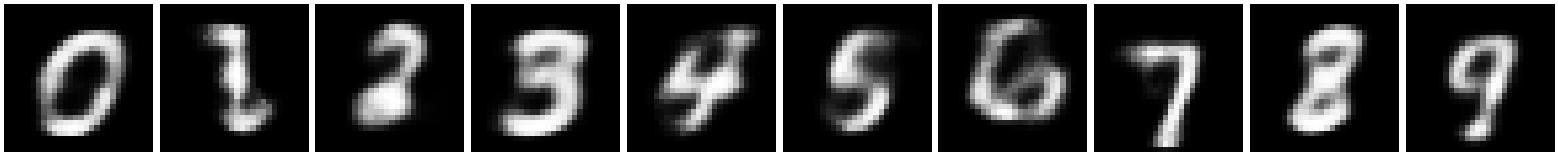

hidden_dim sweep | latent_size=15 | hidden_dim=64


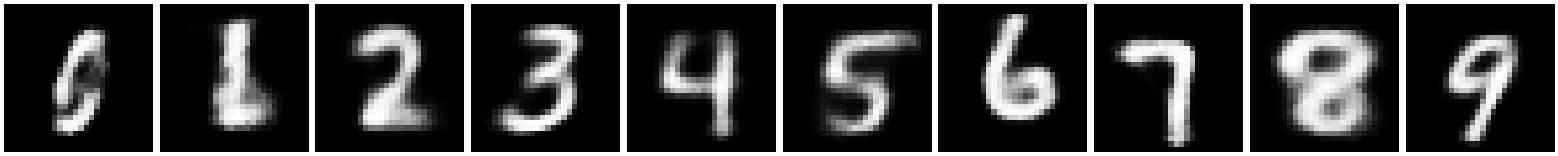

hidden_dim sweep | latent_size=15 | hidden_dim=128


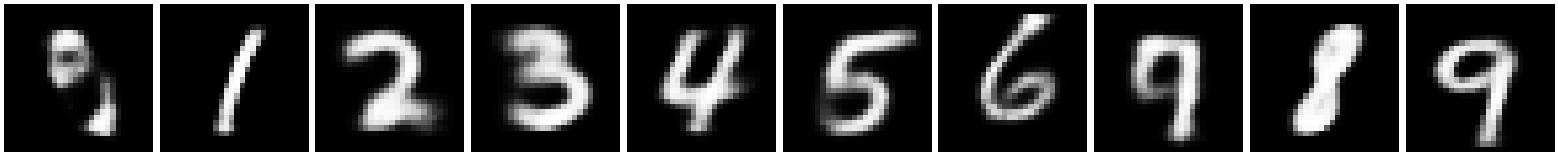

hidden_dim sweep | latent_size=15 | hidden_dim=256


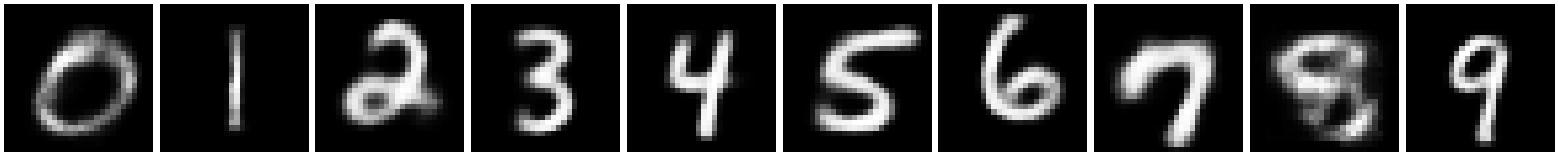

In [ ]:
# Qualitative evaluation of CVAE image synthesis under independent hyperparameter sweeps.
# Run this cell after CVAE, loss_function, loader_train and device have been defined.

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from IPython.display import display, Image as IPyImage

# Where to save generated samples and result tables.
BASE_OUTPUT_DIR = GOOGLE_DRIVE_PATH if "GOOGLE_DRIVE_PATH" in globals() else "."
RESULTS_DIR = os.path.join(BASE_OUTPUT_DIR, "cvae_hyperparameter_results")
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_experiment_seed(seed=0):
    """Make training and sampling more reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def labels_to_one_hot(labels, num_classes=10):
    """One-hot encode labels directly on the active device."""
    labels = labels.to(device)
    return F.one_hot(labels, num_classes=num_classes).float()


def train_cvae_one_epoch(model, train_loader, optimizer, max_batches=None):
    """Train one CVAE epoch and return the mean batch loss."""
    model.train()
    epoch_losses = []

    for batch_idx, (data, labels) in enumerate(train_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        data = data.to(device)
        labels_onehot = labels_to_one_hot(labels, num_classes=10)

        recon_batch, mu, logvar = model(data, labels_onehot)
        loss = loss_function(recon_batch, data, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))


@torch.no_grad()
def evaluate_cvae_train_loss(model, train_loader, max_batches=None):
    """Evaluate the loss over the training data without updating weights."""
    model.eval()
    losses = []

    for batch_idx, (data, labels) in enumerate(train_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        data = data.to(device)
        labels_onehot = labels_to_one_hot(labels, num_classes=10)
        recon_batch, mu, logvar = model(data, labels_onehot)
        loss = loss_function(recon_batch, data, mu, logvar)
        losses.append(loss.item())

    return float(np.mean(losses))


def train_cvae_experiment(latent_size, hidden_dim, epochs=10, lr=1e-3,
                          max_batches=None, seed=0, verbose=True):
    """Train one CVAE configuration and return the model and loss history."""
    set_experiment_seed(seed)

    model = CVAE(input_size=input_size,
                 latent_size=latent_size,
                 hidden_dim=hidden_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(epochs):
        epoch_loss = train_cvae_one_epoch(model, loader_train, optimizer,
                                          max_batches=max_batches)
        history.append(epoch_loss)
        if verbose:
            print(f"latent_size={latent_size:>2}, hidden_dim={hidden_dim:>3}, "
                  f"epoch={epoch + 1:>2}/{epochs}, mean_loss={epoch_loss:.4f}")

    final_train_loss = evaluate_cvae_train_loss(model, loader_train,
                                                max_batches=max_batches)
    return model, history, final_train_loss


@torch.no_grad()
def save_conditional_generation(model, latent_size, hidden_dim, output_dir=RESULTS_DIR,
                                seed=0, prefix="cvae_cond"):
    """Generate one sample per MNIST class and save a 0--9 image strip."""
    set_experiment_seed(seed)
    model.eval()

    z = torch.randn(10, latent_size, device=device)
    c = torch.eye(10, 10, device=device)
    decoder_input = torch.cat((z, c), dim=1)
    samples = model.decoder(decoder_input).detach().cpu().numpy()

    save_file = f"{prefix}_generation_latent{latent_size}_hidden{hidden_dim}.jpg"
    save_path = os.path.join(output_dir, save_file)

    fig = plt.figure(figsize=(10, 1))
    for i, sample in enumerate(samples):
        ax = plt.subplot(1, 10, i + 1)
        ax.axis("off")
        ax.set_aspect("equal")
        ax.imshow(sample.reshape(28, 28), cmap="Greys_r")
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.02, dpi=200)
    plt.show()
    plt.close(fig)

    return save_path


def run_independent_qualitative_sweeps(latent_values, hidden_values,
                                       baseline_latent=15, baseline_hidden=128,
                                       epochs=10, max_batches=None, seed=0):
    """
    Run two independent qualitative sweeps:
    1) vary latent_size while keeping hidden_dim fixed;
    2) vary hidden_dim while keeping latent_size fixed.
    """
    rows = []
    completed = {}

    experiments = []
    for latent in latent_values:
        experiments.append(("latent_size sweep", latent, latent, baseline_hidden))
    for hidden in hidden_values:
        experiments.append(("hidden_dim sweep", hidden, baseline_latent, hidden))

    for sweep_name, varied_value, latent_size, hidden_dim in experiments:
        key = (latent_size, hidden_dim)

        if key not in completed:
            print("\n" + "=" * 80)
            print(f"Training CVAE: latent_size={latent_size}, hidden_dim={hidden_dim}")
            model, history, final_train_loss = train_cvae_experiment(
                latent_size=latent_size,
                hidden_dim=hidden_dim,
                epochs=epochs,
                max_batches=max_batches,
                seed=seed,
                verbose=True
            )
            image_path = save_conditional_generation(
                model,
                latent_size=latent_size,
                hidden_dim=hidden_dim,
                seed=seed,
                prefix="cvae_cond"
            )
            completed[key] = {
                "history": history,
                "final_train_loss": final_train_loss,
                "image_path": image_path
            }

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        rows.append({
            "sweep": sweep_name,
            "varied_value": varied_value,
            "latent_size": latent_size,
            "hidden_dim": hidden_dim,
            "final_train_loss": completed[key]["final_train_loss"],
            "image_path": completed[key]["image_path"],
            # Fill these two columns after visually inspecting each saved strip.
            "subjective_quality_1_to_5": "",
            "visual_notes": ""
        })

    results = pd.DataFrame(rows)
    csv_path = os.path.join(RESULTS_DIR, "qualitative_independent_sweeps.csv")
    results.to_csv(csv_path, index=False)
    print(f"\nSaved qualitative sweep table to: {csv_path}")
    return results


# Main qualitative experiment.
# For a full run keep QUAL_MAX_BATCHES=None. For a quick dry run, set it to e.g. 100.
QUAL_EPOCHS = 10
QUAL_MAX_BATCHES = None
BASELINE_LATENT_SIZE = 15
BASELINE_HIDDEN_DIM = 128

LATENT_SIZE_VALUES = [2, 5, 10, 15, 30]
HIDDEN_DIM_VALUES = [32, 64, 128, 256]

qualitative_results = run_independent_qualitative_sweeps(
    latent_values=LATENT_SIZE_VALUES,
    hidden_values=HIDDEN_DIM_VALUES,
    baseline_latent=BASELINE_LATENT_SIZE,
    baseline_hidden=BASELINE_HIDDEN_DIM,
    epochs=QUAL_EPOCHS,
    max_batches=QUAL_MAX_BATCHES,
    seed=0
)

# Optional: display the saved strips again from the files.
for _, row in qualitative_results.iterrows():
    print(f"{row['sweep']} | latent_size={row['latent_size']} | hidden_dim={row['hidden_dim']}")
    display(IPyImage(filename=row["image_path"]))



Once the csv file is created, we complete it with our considerations.

In [ ]:
from pathlib import Path
results_dir = Path("/content/drive/MyDrive/DLVSP/DLVSP2/Lab2/cvae_hyperparameter_results")

csv_path = results_dir / "qualitative_independent_sweeps.csv"

df = pd.read_csv(csv_path)

display(df)

,sweep,varied_value,latent_size,hidden_dim,final_train_loss,image_path,subjective_quality_1_to_5,visual_notes
0,latent_size sweep,2,2,128,132.105126,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,4.2,Very clear class conditioning: all digits from...
1,latent_size sweep,5,5,128,119.112090,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,3.6,"Most classes are recognizable, but several sam..."
2,latent_size sweep,10,10,128,113.033496,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,3.8,Good overall quality and lower loss than laten...
3,latent_size sweep,15,15,128,112.011307,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,3.1,Although this configuration has the lowest los...
4,latent_size sweep,30,30,128,113.041482,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,4.0,Strong visual quality with clear conditioning ...
5,hidden_dim sweep,32,15,32,133.218349,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,3.5,"Under-capacity model according to the loss, bu..."
6,hidden_dim sweep,64,15,64,122.485139,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,3.7,Clear improvement over hidden_dim=32 in loss a...
7,hidden_dim sweep,128,15,128,112.011307,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,3.1,"Same visual result as the latent_size=15, hidd..."
8,hidden_dim sweep,256,15,256,110.790616,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...,4.1,Best loss in the hidden-dim sweep and one of t...


Design experiments to find the best combination of hyperparameters (`latent_size` and `hidden_dim`) in terms of the value of the loss over the training data. AI-powered generation of code can be a great starting point to implement your test proposals


Grid-search run: latent_size=5, hidden_dim=64
latent_size= 5, hidden_dim= 64, epoch= 1/10, mean_loss=213.0059
latent_size= 5, hidden_dim= 64, epoch= 2/10, mean_loss=166.3285
latent_size= 5, hidden_dim= 64, epoch= 3/10, mean_loss=146.5584
latent_size= 5, hidden_dim= 64, epoch= 4/10, mean_loss=138.6184
latent_size= 5, hidden_dim= 64, epoch= 5/10, mean_loss=133.6992
latent_size= 5, hidden_dim= 64, epoch= 6/10, mean_loss=130.3054
latent_size= 5, hidden_dim= 64, epoch= 7/10, mean_loss=128.0261
latent_size= 5, hidden_dim= 64, epoch= 8/10, mean_loss=126.2728
latent_size= 5, hidden_dim= 64, epoch= 9/10, mean_loss=124.9265
latent_size= 5, hidden_dim= 64, epoch=10/10, mean_loss=123.8233


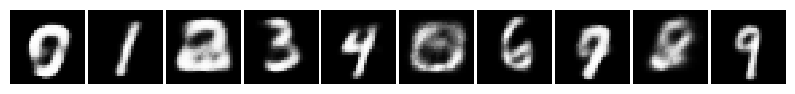


Grid-search run: latent_size=5, hidden_dim=128
latent_size= 5, hidden_dim=128, epoch= 1/10, mean_loss=196.6500
latent_size= 5, hidden_dim=128, epoch= 2/10, mean_loss=151.4225
latent_size= 5, hidden_dim=128, epoch= 3/10, mean_loss=136.1518
latent_size= 5, hidden_dim=128, epoch= 4/10, mean_loss=128.7024
latent_size= 5, hidden_dim=128, epoch= 5/10, mean_loss=125.6719
latent_size= 5, hidden_dim=128, epoch= 6/10, mean_loss=123.8063
latent_size= 5, hidden_dim=128, epoch= 7/10, mean_loss=122.3842
latent_size= 5, hidden_dim=128, epoch= 8/10, mean_loss=121.3282
latent_size= 5, hidden_dim=128, epoch= 9/10, mean_loss=120.5140
latent_size= 5, hidden_dim=128, epoch=10/10, mean_loss=119.6984


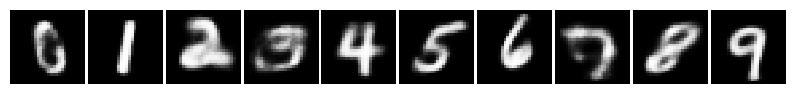


Grid-search run: latent_size=5, hidden_dim=256
latent_size= 5, hidden_dim=256, epoch= 1/10, mean_loss=181.7046
latent_size= 5, hidden_dim=256, epoch= 2/10, mean_loss=138.2023
latent_size= 5, hidden_dim=256, epoch= 3/10, mean_loss=127.0527
latent_size= 5, hidden_dim=256, epoch= 4/10, mean_loss=123.3041
latent_size= 5, hidden_dim=256, epoch= 5/10, mean_loss=120.3168
latent_size= 5, hidden_dim=256, epoch= 6/10, mean_loss=116.6597
latent_size= 5, hidden_dim=256, epoch= 7/10, mean_loss=114.4769
latent_size= 5, hidden_dim=256, epoch= 8/10, mean_loss=112.8581
latent_size= 5, hidden_dim=256, epoch= 9/10, mean_loss=111.7336
latent_size= 5, hidden_dim=256, epoch=10/10, mean_loss=110.8464


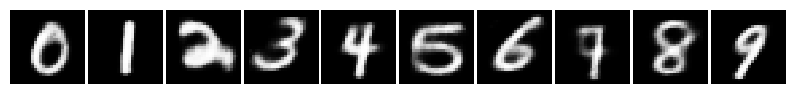


Grid-search run: latent_size=10, hidden_dim=64
latent_size=10, hidden_dim= 64, epoch= 1/10, mean_loss=213.3257
latent_size=10, hidden_dim= 64, epoch= 2/10, mean_loss=169.0548
latent_size=10, hidden_dim= 64, epoch= 3/10, mean_loss=149.9451
latent_size=10, hidden_dim= 64, epoch= 4/10, mean_loss=140.7540
latent_size=10, hidden_dim= 64, epoch= 5/10, mean_loss=134.8502
latent_size=10, hidden_dim= 64, epoch= 6/10, mean_loss=131.6502
latent_size=10, hidden_dim= 64, epoch= 7/10, mean_loss=129.6313
latent_size=10, hidden_dim= 64, epoch= 8/10, mean_loss=128.2183
latent_size=10, hidden_dim= 64, epoch= 9/10, mean_loss=127.0674
latent_size=10, hidden_dim= 64, epoch=10/10, mean_loss=126.2523


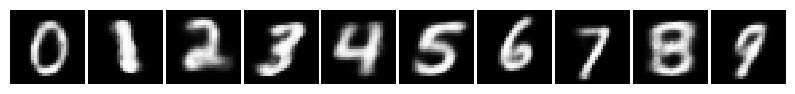


Grid-search run: latent_size=10, hidden_dim=128
latent_size=10, hidden_dim=128, epoch= 1/10, mean_loss=199.8519
latent_size=10, hidden_dim=128, epoch= 2/10, mean_loss=149.7391
latent_size=10, hidden_dim=128, epoch= 3/10, mean_loss=135.0776
latent_size=10, hidden_dim=128, epoch= 4/10, mean_loss=128.3889
latent_size=10, hidden_dim=128, epoch= 5/10, mean_loss=123.6350
latent_size=10, hidden_dim=128, epoch= 6/10, mean_loss=120.0785
latent_size=10, hidden_dim=128, epoch= 7/10, mean_loss=117.7528
latent_size=10, hidden_dim=128, epoch= 8/10, mean_loss=116.0390
latent_size=10, hidden_dim=128, epoch= 9/10, mean_loss=114.6593
latent_size=10, hidden_dim=128, epoch=10/10, mean_loss=113.6057


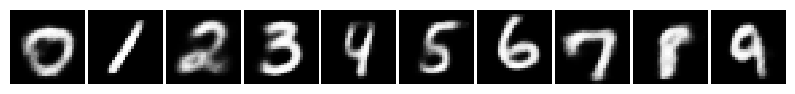


Grid-search run: latent_size=10, hidden_dim=256
latent_size=10, hidden_dim=256, epoch= 1/10, mean_loss=183.2725
latent_size=10, hidden_dim=256, epoch= 2/10, mean_loss=136.9002
latent_size=10, hidden_dim=256, epoch= 3/10, mean_loss=127.3558
latent_size=10, hidden_dim=256, epoch= 4/10, mean_loss=123.4790
latent_size=10, hidden_dim=256, epoch= 5/10, mean_loss=120.0673
latent_size=10, hidden_dim=256, epoch= 6/10, mean_loss=116.8559
latent_size=10, hidden_dim=256, epoch= 7/10, mean_loss=114.8950
latent_size=10, hidden_dim=256, epoch= 8/10, mean_loss=113.4345
latent_size=10, hidden_dim=256, epoch= 9/10, mean_loss=112.3643
latent_size=10, hidden_dim=256, epoch=10/10, mean_loss=111.5283


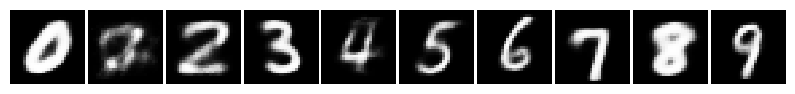


Grid-search run: latent_size=15, hidden_dim=64
latent_size=15, hidden_dim= 64, epoch= 1/10, mean_loss=214.8232
latent_size=15, hidden_dim= 64, epoch= 2/10, mean_loss=167.1806
latent_size=15, hidden_dim= 64, epoch= 3/10, mean_loss=148.5893
latent_size=15, hidden_dim= 64, epoch= 4/10, mean_loss=138.1538
latent_size=15, hidden_dim= 64, epoch= 5/10, mean_loss=133.0504
latent_size=15, hidden_dim= 64, epoch= 6/10, mean_loss=129.8156
latent_size=15, hidden_dim= 64, epoch= 7/10, mean_loss=127.4600
latent_size=15, hidden_dim= 64, epoch= 8/10, mean_loss=125.6230
latent_size=15, hidden_dim= 64, epoch= 9/10, mean_loss=124.1948
latent_size=15, hidden_dim= 64, epoch=10/10, mean_loss=123.1774


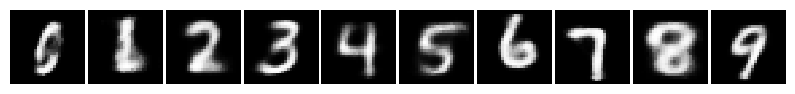


Grid-search run: latent_size=15, hidden_dim=128
latent_size=15, hidden_dim=128, epoch= 1/10, mean_loss=198.9062
latent_size=15, hidden_dim=128, epoch= 2/10, mean_loss=148.0252
latent_size=15, hidden_dim=128, epoch= 3/10, mean_loss=133.1944
latent_size=15, hidden_dim=128, epoch= 4/10, mean_loss=125.4454
latent_size=15, hidden_dim=128, epoch= 5/10, mean_loss=120.9395
latent_size=15, hidden_dim=128, epoch= 6/10, mean_loss=118.1446
latent_size=15, hidden_dim=128, epoch= 7/10, mean_loss=116.3194
latent_size=15, hidden_dim=128, epoch= 8/10, mean_loss=114.9507
latent_size=15, hidden_dim=128, epoch= 9/10, mean_loss=113.8258
latent_size=15, hidden_dim=128, epoch=10/10, mean_loss=112.8215


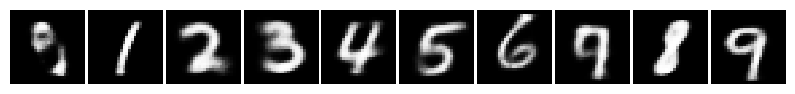


Grid-search run: latent_size=15, hidden_dim=256
latent_size=15, hidden_dim=256, epoch= 1/10, mean_loss=187.3227
latent_size=15, hidden_dim=256, epoch= 2/10, mean_loss=139.9578
latent_size=15, hidden_dim=256, epoch= 3/10, mean_loss=128.1963
latent_size=15, hidden_dim=256, epoch= 4/10, mean_loss=123.9886
latent_size=15, hidden_dim=256, epoch= 5/10, mean_loss=120.0251
latent_size=15, hidden_dim=256, epoch= 6/10, mean_loss=116.8570
latent_size=15, hidden_dim=256, epoch= 7/10, mean_loss=114.9661
latent_size=15, hidden_dim=256, epoch= 8/10, mean_loss=113.5699
latent_size=15, hidden_dim=256, epoch= 9/10, mean_loss=112.4135
latent_size=15, hidden_dim=256, epoch=10/10, mean_loss=111.6204


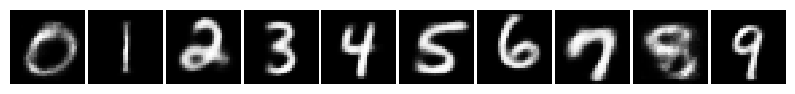


Grid-search run: latent_size=30, hidden_dim=64
latent_size=30, hidden_dim= 64, epoch= 1/10, mean_loss=215.5696
latent_size=30, hidden_dim= 64, epoch= 2/10, mean_loss=171.4145
latent_size=30, hidden_dim= 64, epoch= 3/10, mean_loss=147.6455
latent_size=30, hidden_dim= 64, epoch= 4/10, mean_loss=138.2313
latent_size=30, hidden_dim= 64, epoch= 5/10, mean_loss=132.7047
latent_size=30, hidden_dim= 64, epoch= 6/10, mean_loss=129.4313
latent_size=30, hidden_dim= 64, epoch= 7/10, mean_loss=127.1488
latent_size=30, hidden_dim= 64, epoch= 8/10, mean_loss=125.4499
latent_size=30, hidden_dim= 64, epoch= 9/10, mean_loss=124.0094
latent_size=30, hidden_dim= 64, epoch=10/10, mean_loss=122.9519


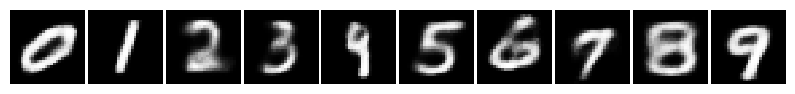


Grid-search run: latent_size=30, hidden_dim=128
latent_size=30, hidden_dim=128, epoch= 1/10, mean_loss=201.3408
latent_size=30, hidden_dim=128, epoch= 2/10, mean_loss=152.6204
latent_size=30, hidden_dim=128, epoch= 3/10, mean_loss=135.1978
latent_size=30, hidden_dim=128, epoch= 4/10, mean_loss=126.3888
latent_size=30, hidden_dim=128, epoch= 5/10, mean_loss=121.9849
latent_size=30, hidden_dim=128, epoch= 6/10, mean_loss=119.2163
latent_size=30, hidden_dim=128, epoch= 7/10, mean_loss=117.1937
latent_size=30, hidden_dim=128, epoch= 8/10, mean_loss=115.6502
latent_size=30, hidden_dim=128, epoch= 9/10, mean_loss=114.5021
latent_size=30, hidden_dim=128, epoch=10/10, mean_loss=113.5801


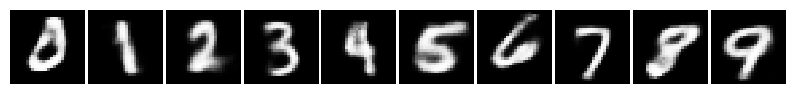


Grid-search run: latent_size=30, hidden_dim=256
latent_size=30, hidden_dim=256, epoch= 1/10, mean_loss=190.3263
latent_size=30, hidden_dim=256, epoch= 2/10, mean_loss=140.2284
latent_size=30, hidden_dim=256, epoch= 3/10, mean_loss=126.9087
latent_size=30, hidden_dim=256, epoch= 4/10, mean_loss=121.9203
latent_size=30, hidden_dim=256, epoch= 5/10, mean_loss=118.9935
latent_size=30, hidden_dim=256, epoch= 6/10, mean_loss=116.8394
latent_size=30, hidden_dim=256, epoch= 7/10, mean_loss=115.0980
latent_size=30, hidden_dim=256, epoch= 8/10, mean_loss=113.7758
latent_size=30, hidden_dim=256, epoch= 9/10, mean_loss=112.6816
latent_size=30, hidden_dim=256, epoch=10/10, mean_loss=111.7740


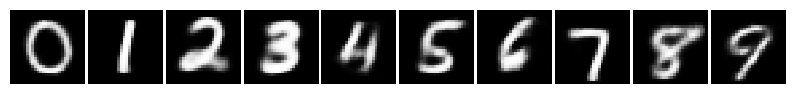


Best configuration according to final training loss:
latent_size=5, hidden_dim=256, final_train_loss=110.2296
Saved grid-search table to: drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperparameter_results/cvae_loss_grid_search.csv


,latent_size,hidden_dim,epochs,final_train_loss,last_epoch_mean_loss,image_path
2,5,256,10,110.229597,110.846378,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
5,10,256,10,110.740132,111.528304,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
8,15,256,10,110.790616,111.620387,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
11,30,256,10,110.939647,111.774004,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
7,15,128,10,112.011307,112.821488,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
4,10,128,10,113.033496,113.605676,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
10,30,128,10,113.041482,113.580102,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
1,5,128,10,119.112090,119.698369,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
9,30,64,10,122.168254,122.951914,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...
6,15,64,10,122.485139,123.177449,drive/My Drive/DLVSP/DLVSP2/Lab2/cvae_hyperpar...


In [ ]:
# Grid search: choose the best hyperparameter combination by training loss.
# This experiment varies latent_size and hidden_dim jointly.

import itertools

GRID_LATENT_SIZES = [5, 10, 15, 30]
GRID_HIDDEN_DIMS = [64, 128, 256]
GRID_EPOCHS = 10
GRID_MAX_BATCHES = None  # set e.g. to 100 only for a quick dry run


def run_loss_grid_search(latent_sizes, hidden_dims, epochs=10, max_batches=None, seed=0):
    rows = []

    for latent_size, hidden_dim in itertools.product(latent_sizes, hidden_dims):
        print("\n" + "=" * 80)
        print(f"Grid-search run: latent_size={latent_size}, hidden_dim={hidden_dim}")

        model, history, final_train_loss = train_cvae_experiment(
            latent_size=latent_size,
            hidden_dim=hidden_dim,
            epochs=epochs,
            max_batches=max_batches,
            seed=seed,
            verbose=True
        )

        # Save a generated strip for qualitative comparison too.
        image_path = save_conditional_generation(
            model,
            latent_size=latent_size,
            hidden_dim=hidden_dim,
            seed=seed,
            prefix="cvae_grid"
        )

        rows.append({
            "latent_size": latent_size,
            "hidden_dim": hidden_dim,
            "epochs": epochs,
            "final_train_loss": final_train_loss,
            "last_epoch_mean_loss": history[-1],
            "image_path": image_path
        })

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    grid_results = pd.DataFrame(rows).sort_values("final_train_loss", ascending=True)
    csv_path = os.path.join(RESULTS_DIR, "cvae_loss_grid_search.csv")
    grid_results.to_csv(csv_path, index=False)

    best = grid_results.iloc[0]
    print("\nBest configuration according to final training loss:")
    print(f"latent_size={int(best['latent_size'])}, "
          f"hidden_dim={int(best['hidden_dim'])}, "
          f"final_train_loss={best['final_train_loss']:.4f}")
    print(f"Saved grid-search table to: {csv_path}")

    display(grid_results)
    return grid_results


grid_results = run_loss_grid_search(
    latent_sizes=GRID_LATENT_SIZES,
    hidden_dims=GRID_HIDDEN_DIMS,
    epochs=GRID_EPOCHS,
    max_batches=GRID_MAX_BATCHES,
    seed=0
)

Once the csv is generated, we use it to plot the losses on a graph.

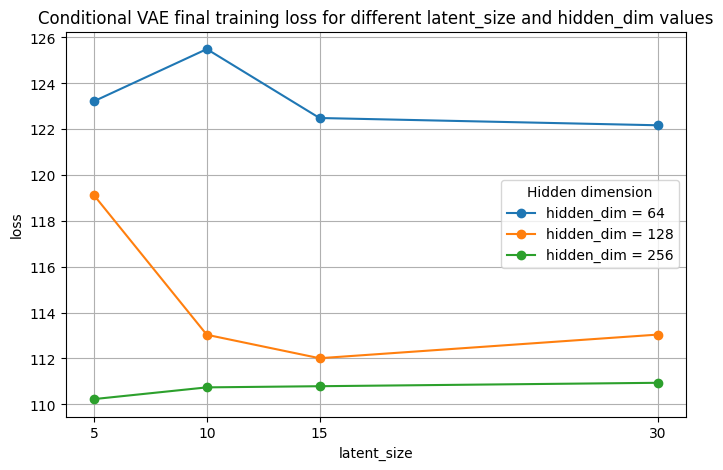

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("/content/drive/MyDrive/DLVSP/DLVSP2/Lab2/cvae_hyperparameter_results/cvae_loss_grid_search.csv")

# Make sure the data are sorted
df = df.sort_values(["latent_size", "hidden_dim"])

# Plot: x = latent_size, y = loss
plt.figure(figsize=(8, 5))

for hidden_dim in [64, 128, 256]:
    subset = df[df["hidden_dim"] == hidden_dim]

    plt.plot(
        subset["latent_size"],
        subset["final_train_loss"],
        marker="o",
        label=f"hidden_dim = {hidden_dim}"
    )

plt.xlabel("latent_size")
plt.ylabel("loss")
plt.title("Conditional VAE final training loss for different latent_size and hidden_dim values")
plt.xticks(sorted(df["latent_size"].unique()))
plt.legend(title="Hidden dimension")
plt.grid(True)
plt.show()